# TAREA 1 MACHINE LEARNING: TERREMOTOS
### **Fabián Carvajal y Bastián Paredes**

## Pregunta a Investigar
#### ¿La profundidad tiene relacion con el lugar del sismo?

## Desafío
#### ¿Podemos afirmar, a partir de estos datos, que últimamente está temblando más?

In [7]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd 
import seaborn as sns

## COMPRENDIENDO LA MUESTRA

### Observaciones y Poblaciones

In [8]:
df = pd.read_csv("earthquakes_usgs.csv")


#### **¿Qué representa una observación?**

Una observarcion es un evento sísmico registrado, el cual tiene atributos como la ubicacion del sismo, la fecha, su magnitud y más.

In [9]:
df

,Unnamed: 0,time,latitude,longitude,depth,mag,magType,place,type,status,net,nst,rms
0,0,1900-01-05T19:00:00.000Z,-3.0000,102.0000,NaN,7.0,ms,"Southern Sumatra, Indonesia",earthquake,reviewed,cent,NaN,NaN
1,1,1900-01-11T09:07:00.000Z,-5.0000,148.0000,NaN,7.0,ms,Bismarck Sea,earthquake,reviewed,cent,NaN,NaN
2,2,1900-01-20T06:33:00.000Z,20.0000,-105.0000,NaN,7.3,mw,"Jalisco, Mexico",earthquake,reviewed,cent,NaN,NaN
3,3,1900-01-31T19:22:00.000Z,48.0000,146.0000,450.000,7.5,mj,Sea of Okhotsk,earthquake,reviewed,cent,NaN,NaN
4,4,1900-04-30T22:41:14.000Z,36.9000,-121.6000,NaN,4.5,ml,"Near Aromas, California",earthquake,reviewed,ushis,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
310530,310530,2026-08-26T07:32:17.399Z,44.6862,146.4404,159.458,4.7,mb,"82 km NE of Otrada, Russia",earthquake,reviewed,us,68.0,0.77
310531,310531,2026-08-26T09:47:34.473Z,-8.3296,121.3370,10.000,4.6,mb,"67 km NNW of Ende, Indonesia",earthquake,reviewed,us,31.0,0.68
310532,310532,2026-08-26T09:51:22.122Z,21.5368,122.3274,10.000,4.6,mb,"126 km NNE of Basco, Philippines",earthquake,reviewed,us,45.0,0.50
310533,310533,2026-08-26T14:15:31.234Z,-8.3715,121.5083,10.000,5.0,mww,"54 km NNW of Ende, Indonesia",earthquake,reviewed,us,71.0,0.76


Text(0.5, 1.0, 'Magnitud mínima registrada por año')

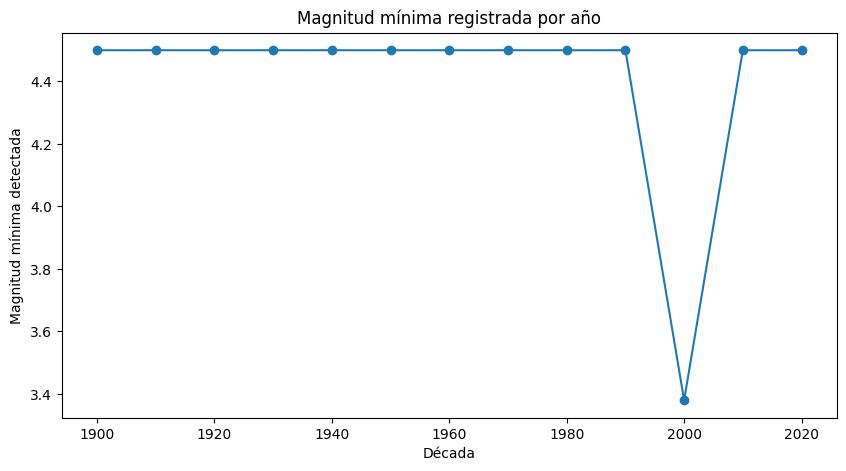

In [10]:
df['time'] = pd.to_datetime(df['time'])
df['decade'] = (df['time'].dt.year // 10) * 10

mag_min_anual = df.groupby('decade')['mag'].min()

plt.figure(figsize=(10,5))
mag_min_anual.plot(marker='o')
plt.xlabel("Década")
plt.ylabel('Magnitud mínima detectada')
plt.title('Magnitud mínima registrada por año')


#### **¿Qué población esta siendo estudiada?**

La población es una muestra de sismos registrados desde 1900 hasta 2025, la cual parece tener una mascara en la magnitud con mag $ \geq 4.5$

### Features

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 310535 entries, 0 to 310534
Data columns (total 14 columns):
 #   Column      Non-Null Count   Dtype              
---  ------      --------------   -----              
 0   Unnamed: 0  310535 non-null  int64              
 1   time        310535 non-null  datetime64[us, UTC]
 2   latitude    310535 non-null  float64            
 3   longitude   310535 non-null  float64            
 4   depth       309808 non-null  float64            
 5   mag         310535 non-null  float64            
 6   magType     310534 non-null  str                
 7   place       310535 non-null  str                
 8   type        310535 non-null  str                
 9   status      310535 non-null  str                
 10  net         310535 non-null  str                
 11  nst         120314 non-null  float64            
 12  rms         260523 non-null  float64            
 13  decade      310535 non-null  int32              
dtypes: datetime64[us, UTC](1), floa

#### **¿Cuáles son las principales features?¿Qué tipo de información contiene cada una?**

Cada fila del archivo corresponde a **un terremoto**.

Las principales características son:

- `mag`: número que indica la magnitud del sismo
- `depth`: profundidad en kilometros en la que fue el epicentro
- `longitude` y `latitude`: coordenadas geográficas de cada sismo registrado 
- `time`: indica la fecha y hora en la que ocurrio cada sismo

También, otras características como:

- `magType`: el tipo de magnitud en la que se midio el sismo
- `place`: indica la ciudad y el país en el que ocurrio el sismo
- `type`: tipo de evento natural (todos son earthquake)
- `status`: es el estado del evento, si ha sido revisado o no
- `net`: el identificador de la red sísmica que procesó o reportó originalmente el evento.
- `nst`: número de instrumentos que detectaron el sismo
- `rms`: imprecisión que se puede llegar a tener sobre el evento


#### **¿Existen valores Faltantes?**

In [12]:
datos_faltantes = df.isnull().sum()
datos_faltantes

Unnamed: 0         0
time               0
latitude           0
longitude          0
depth            727
mag                0
magType            1
place              0
type               0
status             0
net                0
nst           190221
rms            50012
decade             0
dtype: int64

Se puede ver que galtan 727 valores para la profundidad, uno para el tipo de magnitud, 190221 para el nst y 50012 para el rms.

#### **¿Hay alguna limitación importante en la forma en la que se obtuvieron los datos?**

Hay una limitante bastante marcada y es que todos los sismos son mayores o iguales a 4.5 en magnitud, pero esto es simplemente la forma en la que se tomaron o consideraron los datos. A excepción de un solo dato que es menor a 4.5 en magnitud, que tiene estatus automatic, no reviewed como todos los demas. 
Además, el hecho de que existan varios tipos de magnitudes complica un poco el análisis, ya que mete la duda de si es válido comparar las magnitudes de los terremotos aunque hayan sido tomados con diferentes magnitudes. 

## EXPLORANDO LA MUESTRA

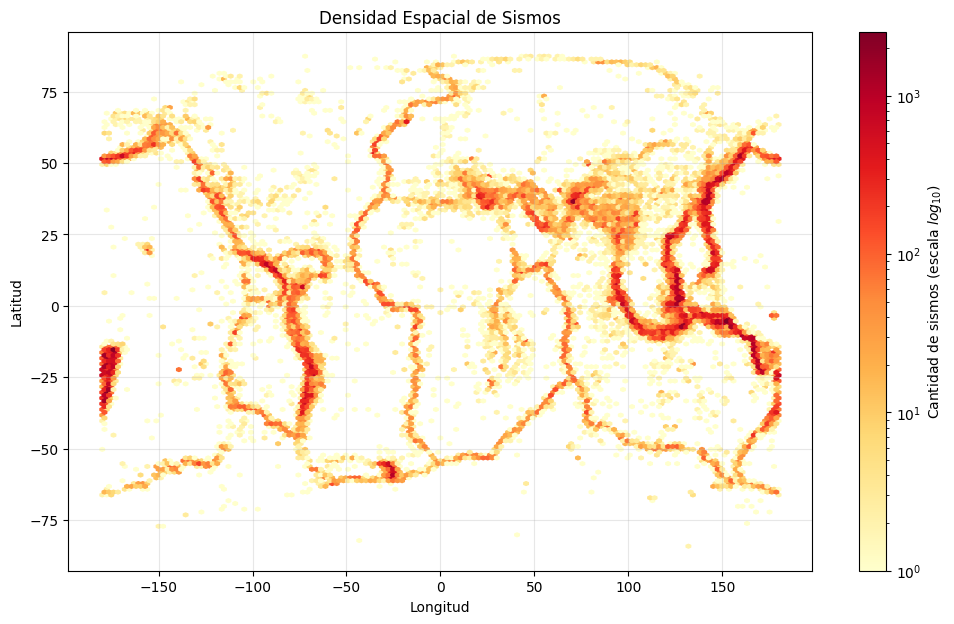

In [13]:
plt.figure(figsize=(12, 7))

# Grid hexagonal (ajusta gridsize para mayor o menor resolución)
hb = plt.hexbin(
    df['longitude'], 
    df['latitude'], 
    gridsize=150, 
    cmap='YlOrRd', 
    mincnt=1, 
    bins='log' # Escala logarítmica recomendada si hay zonas con miles de sismos y otras con pocos
)

cb = plt.colorbar(hb, label='Cantidad de sismos (escala $log_{10}$)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Densidad Espacial de Sismos')
plt.grid(True, alpha=0.3)
plt.show()

Se observa que la distribución de los sismos registrados no tienen una distribución aleatoria, siguen los límites de las placas tectónicas existentes en nuestro planeta. De hecho los lugares más sismicos (más rojos) son Chile, Perú, junto con el continente Oceánico, más Japón y China. El resto del mundo también posee sismos, pero en bastante menor cantidad que los lugares ya mencionados.

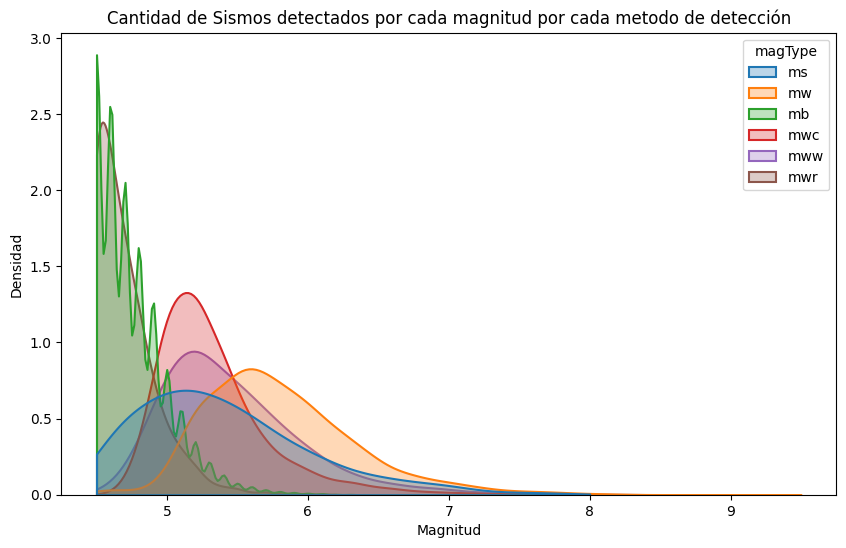

In [14]:
plt.figure(figsize=(10,6))
top_types = df['magType'].value_counts().nlargest(6).index
df_filtered = df[df['magType'].isin(top_types)]
sns.kdeplot(data=df_filtered, x='mag', hue='magType', common_norm=False, fill=True, alpha=0.3, linewidth=1.5, cut=0, bw_adjust=1.5)
plt.xlabel("Magnitud")
plt.ylabel("Densidad")
plt.title("Cantidad de Sismos detectados por cada magnitud por cada metodo de detección")
plt.show()

Se puede observar que los sismos de baja magnitud suelen ser detectados en su mayoría como mb (magnitud de ondas de cuerpo), pero esta escala satura y pierde precisión a magnitudes más altas. En cambio, para magnitudes mayores dominan las variantes de magnitud de momento (mw, mwc centroide, mww fase W), que no se saturan y logran capturar sismos más grandes con mayor precisión.

/tmp/ipykernel_221431/619708774.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot( data=df_mag6, x='mag', hue='magType', common_norm=False, fill=True, alpha=0.3, linewidth=1.5, cut=0, bw_adjust=1.5)


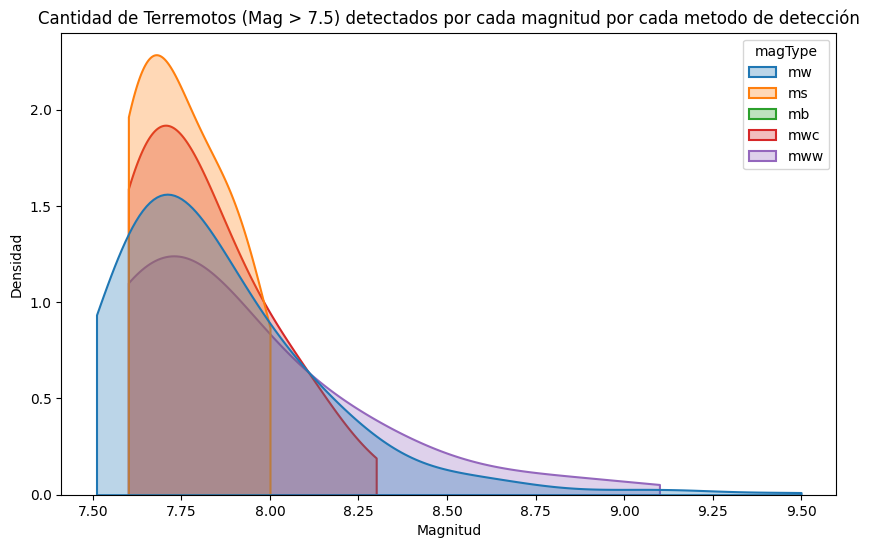

In [15]:
plt.figure(figsize=(10,6))
df_mag6 = df_filtered[df_filtered['mag'] > 7.5]

sns.kdeplot( data=df_mag6, x='mag', hue='magType', common_norm=False, fill=True, alpha=0.3, linewidth=1.5, cut=0, bw_adjust=1.5)
plt.xlabel("Magnitud")
plt.ylabel("Densidad")
plt.title("Cantidad de Terremotos (Mag > 7.5) detectados por cada magnitud por cada metodo de detección")
plt.show()

Aqui se puede observar que estos tipos de magnitud tambien son utiles para magnitudes mayores a 6, pero al ser menos probables hay una menor densidad. 

Para probar el desafío planteado, veamos como se distribuyen los sismos registrados en el tiempo.

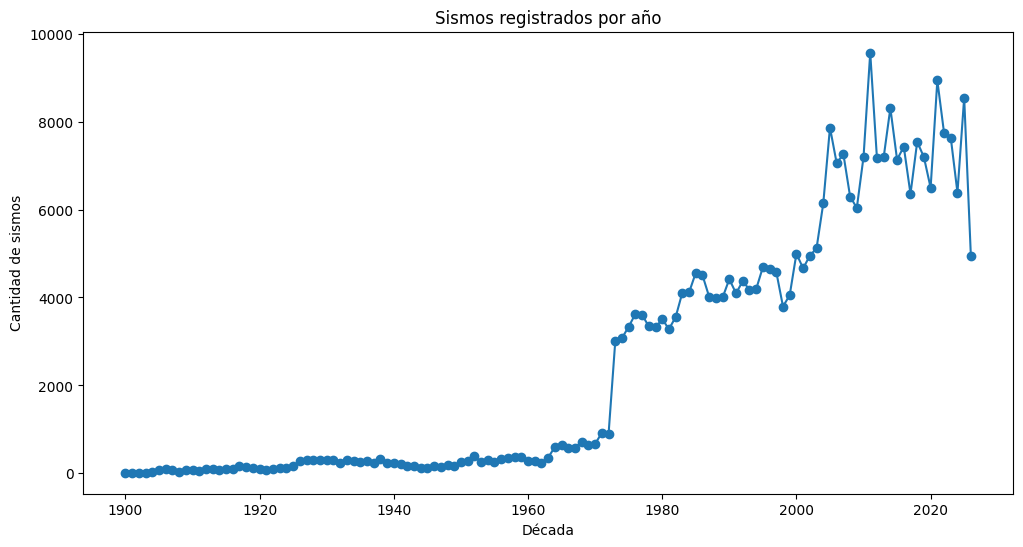

In [16]:
plt.figure(figsize=(12,6))

df['time'] = pd.to_datetime(df['time'])
df['year'] = df['time'].dt.year

conteo_anual = df.groupby('year').size()
conteo_anual.plot(kind='line', marker='o')
plt.xlabel("Década")
plt.ylabel('Cantidad de sismos')
plt.title('Sismos registrados por año')
plt.show()

Este grafico demuestra que se han detectado una mayor cantidad de sismos ultimamente que antes. Lo que plantea dos nuevas interrogantes, esta alza se debe a que en efecto ultimamente hay más sismos? o más bien se debe al desarrollo tecnológico que permite registrar una mayor cantidad de sismos?.

Intentaremos ahora responder a estas dudas, para ello incluiremos en el análisis la magnitud de los sismos.

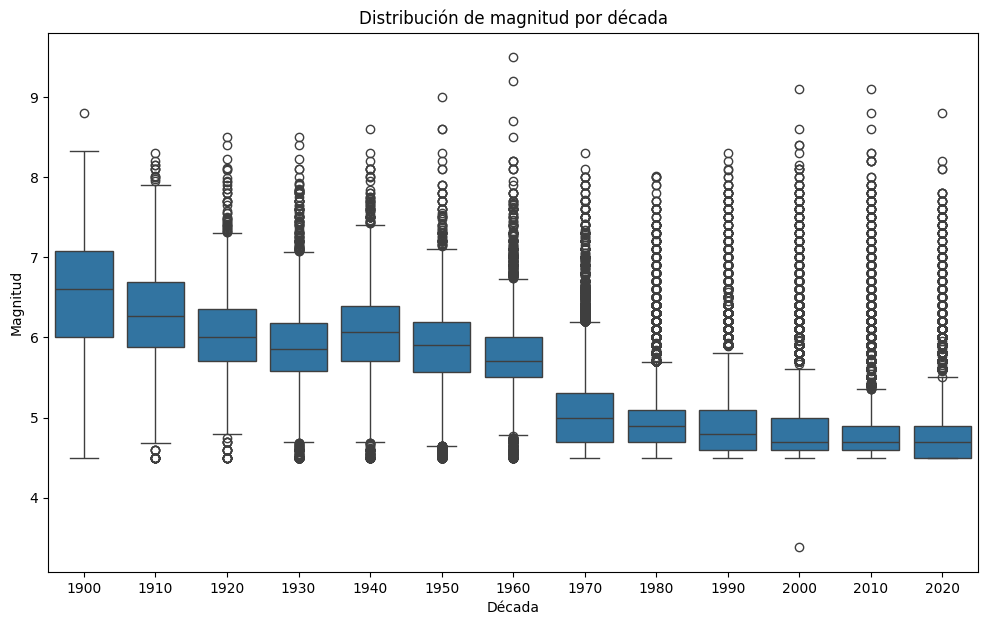

In [17]:
df['decade'] = (df['year'] // 10) * 10

plt.figure(figsize=(12,7))
sns.boxplot(data=df, x='decade', y='mag')
plt.title('Distribución de magnitud por década')
plt.xlabel('Década')
plt.ylabel('Magnitud')
plt.show()

Al pasar el tiempo la media de la magnitud de los sismos va disminuyendo, lo que indicaría que los avances tecnologicos permiten registrar una mayor cantidad de sismos de baja magnitud que a principios del siglo XX. Debdio a que el rango varía bastante poco con el tiempo, y la caja del diagrama se queda en valores bajos, en otras palabras la muestra se concentra en los sismos de baja magnitud.

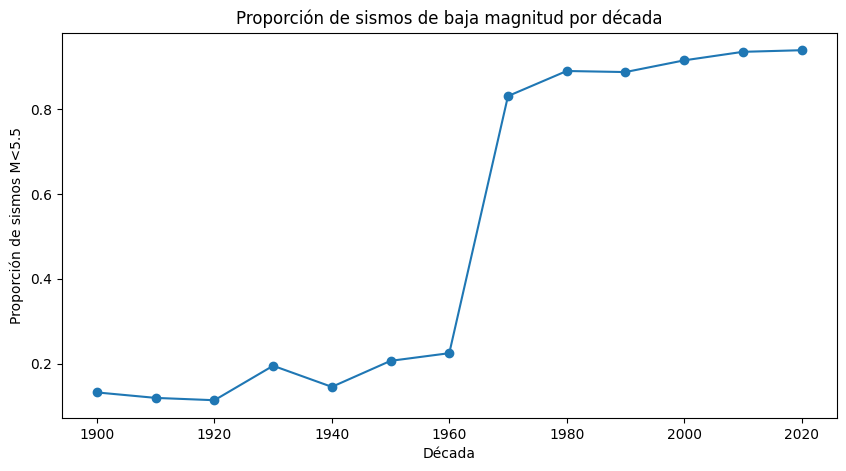

In [18]:
df['mag_baja'] = df['mag'] < 5.5
prop_bajos = df.groupby('decade')['mag_baja'].mean()

plt.figure(figsize=(10,5))
prop_bajos.plot(marker='o')
plt.xlabel("Década")
plt.ylabel('Proporción de sismos M<5.5')
plt.title('Proporción de sismos de baja magnitud por década')
plt.show()

Antes vimos en un grafico que nos indica la magnitud minima registrada cada año que desde 1900, casi todos tenian un limite inferior de 4.5. Pero este grafico nos indica la cantidad de sismos con magnitud inferior a 5.5 durante el tiempo, lo que nos muestra que efectivamente antes se detectaban muchos menos sismos de estas magnitudes. Por lo cual, ya somos capaces de responder a la pregunta del desafío, aun así esto se realizará al final de esta primera sección.

In [19]:
df['pais_region'] = df['place'].str.split(',').str[-1].str.strip()

# 2. Rellenar valores nulos si existen
df['pais_region'] = df['pais_region'].fillna('Desconocido')

# 3. Obtener el Top 15 de lugares con más sismos
top_lugares = df['pais_region'].value_counts().head(10)

print("Top 10 de países/regiones con más sismos:")
print(top_lugares)

Top 10 de países/regiones con más sismos:
pais_region
Indonesia           35624
Japan               20671
Papua New Guinea    17527
Philippines         16158
Russia              13760
Tonga               12054
Chile                9993
Alaska               9762
Vanuatu              9127
Solomon Islands      6656
Name: count, dtype: int64


Ahora se tiene un representación numérica sobre los lugares que poseen una mayor cantidad de sismos. Claramente podemos comprobar que los lugares que poseen más sismos mencionados al inicio del trabajo estaban relativamente correctos.

Pero que tal si ahora analizamos los lugares con más terremotos, considerando un terremoto como un sismo de magnitud mayor a 7.5.

Top países con más terremotos M >= 7.5:
pais_region
Indonesia           49
Japan               36
Papua New Guinea    27
Chile               25
Peru                24
Philippines         24
Russia              22
Mexico              19
Alaska              15
Solomon Islands     14
Name: count, dtype: int64


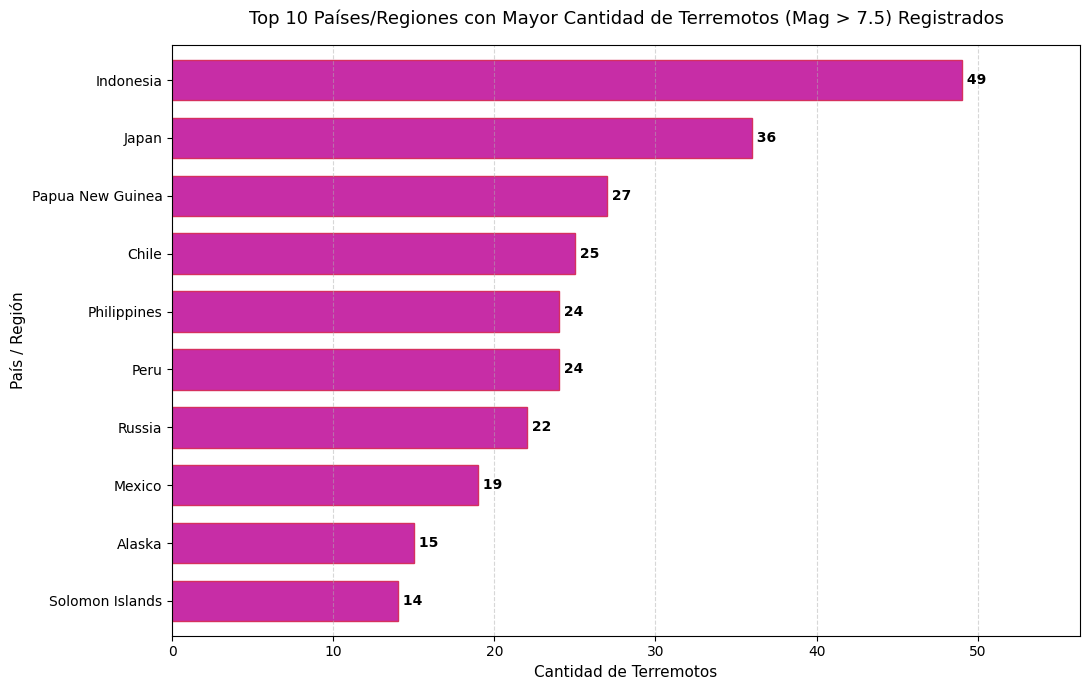

In [20]:
terremotos = df[df['mag'] >= 7.5]
top10_paises = terremotos['pais_region'].value_counts().head(10)
print("Top países con más terremotos M >= 7.5:")
print(top10_paises.head(10))

plt.figure(figsize=(11, 7))

# Graficar ordenando de menor a mayor para que el país #1 quede arriba
top10_paises.sort_values(ascending=True).plot(
    kind='barh', 
    color="#c72da6", 
    edgecolor="#d6305f",
    width=0.7
)

# Añadir etiquetas con el número exacto al final de cada barra
for index, value in enumerate(top10_paises.sort_values(ascending=True)):
    plt.text(value, index, f' {value:,}', va='center', fontsize=10, fontweight='bold')

plt.title('Top 10 Países/Regiones con Mayor Cantidad de Terremotos (Mag > 7.5) Registrados', fontsize=13, pad=15)
plt.xlabel('Cantidad de Terremotos', fontsize=11)
plt.ylabel('País / Región', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Extender el límite del eje X para que quepan los números de la etiqueta
plt.xlim(0, top10_paises.max() * 1.15)

plt.tight_layout()
plt.show()

Se verifica justamente que los lugares más sismicos son propensos a poseer los terremotos de magnitudes más altas.

Agreguemos a la ecuación por primera vez a la profundidad ¿Cómo será el comportamiento de esta variable?

In [21]:
mask = (df['mag'].between(6, 7)) & (df['depth'].between(200, 500))
print(mask.sum())

df['depth_bin'] = pd.cut(df['depth'], bins=range(0, 750, 50))
df[df['mag'].between(6,7)].groupby('depth_bin', observed=True).size()

408


depth_bin
(0, 50]       10628
(50, 100]       915
(100, 150]      428
(150, 200]      222
(200, 250]      157
(250, 300]       57
(300, 350]       25
(350, 400]       60
(400, 450]       58
(450, 500]       48
(500, 550]       82
(550, 600]      166
(600, 650]       97
(650, 700]       10
dtype: int64

Que inesperado!!! Se puede ver que hay un mínimo de densidad en profundidades entre 250 y 550 km ¿Por qué ocurre esto?

Veamos como se relaciona la magnitud con la profundidad de sismo ¿Tendrán alguna relación, o se visualizará mas bien una distribución aleatoria?

<Figure size 900x500 with 0 Axes>

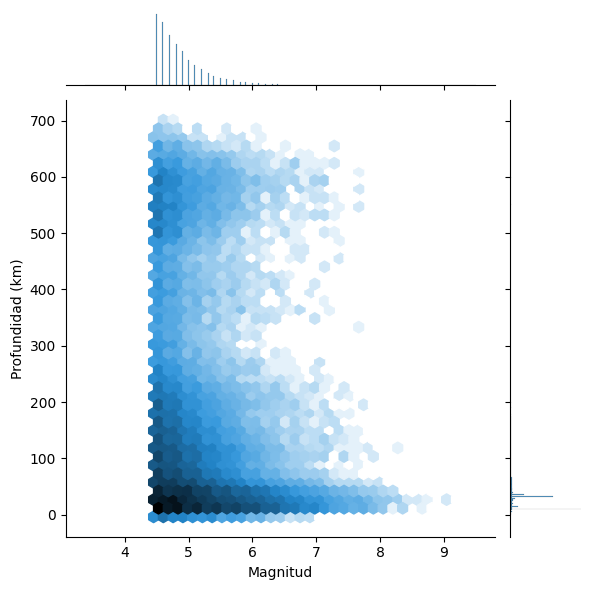

In [22]:
plt.figure(figsize=(9,5))
sns.jointplot( data=df, x='mag', y='depth', kind='hex', gridsize=40, joint_kws={'bins': 'log'})
plt.xlabel('Magnitud')
plt.ylabel('Profundidad (km)')
#plt.title('Distribución de la Magnitud con la Profundidad de los sismos')
plt.show()

Se observa que a mayor magnitud, el rango de profundidades se restringe hacia valores superficiales (sobre M7), casi todos los eventos están bajo 100km, mientras que a magnitudes bajas (4.5-5) hay eventos en todo el rango (0-700km). Esto es consistente con que los sismos más grandes ocurren en el contacto de placas, una zona relativamente superficial.

**RESULTADO INESPERADO**

**Observación:** Al contar eventos M6-7 por rango de profundidad, se observa un gap. La frecuencia cae a un mínimo entre 300-350km y vuelve a subir entre 550-600km, lo cual es inesperado y muetra que la distribucion no decae con la profundidad. Lo que va directamente relacionado con el mínimo de densidad mencionado hace pocos momentos. 

**Hipótesis:** Se debe a la composición de la corteza, con la profundidad la composición de las placas tectónicas empieza a cambiar. No es corteza sólida y dura desde la superficie hasta el manto del planeta donde se encuentra todo el magma, por lo cual en ciertas profundidades no hay placas tectónicas, no hay movimiento de estas y por lo tanto no se generan sismos.
 
**Evidencia adicional:** Se necesitaria conocer la composición de la corteza o de las mismas placas tectónicas a esa profundidad, por ejemplo; `profundidad` = 50.0, `composición` = roca sólida, o en otro caso `profundidad` = 450.0, `composición` = roca blanda/ magma o algo de ese estilo. De este modo se podría llegar a saber que cuando la corteza tiene "cierta" composición en "ciertas" profundidades los sismos o terremotos son menos probables de ocurrir o simplemente no ocurren, 

### **CONCLUSIÓN DEL DESAFÍO**

#### Dicho esto, los datos entregados no nos sirven para concluir que ultimamente tiembla mas que antes. Lo que si podemos concluir es que antes habia menos sensibilidad en los detectores y solo se podian detectar sismos mas fuertes, los cuales son una minoría. Y ahora es posible detectar con mayor facilidad sismos menos fuertes, los cuales son mucho mas comunes. Esto es lo que da la impresion de que ahora tiembla mas, pero es simplemente una limitacion instrumental.

### De aquí en adelante nos esforzaremos en poder responder a la pregunta de investigación, la cual era: ¿La profundidad tiene relacion con el lugar del sismo?

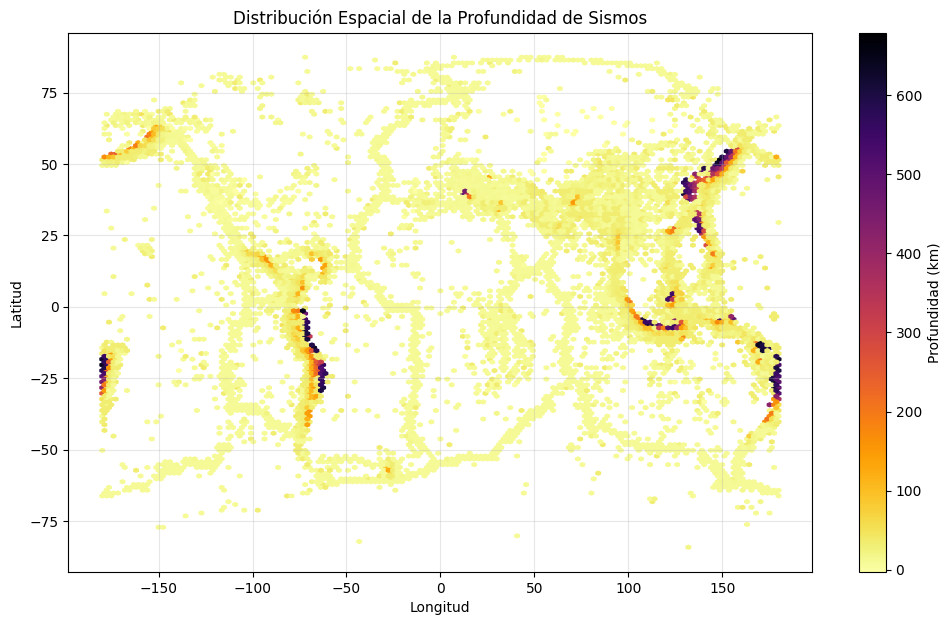

In [23]:
plt.figure(figsize=(12, 7))

# 'C' asigna la variable continua a promediar en cada celda
hb = plt.hexbin(
    df['longitude'], 
    df['latitude'], 
    C=df['depth'], 
    reduce_C_function=np.median, # 'np.mean' o 'np.median'
    gridsize=150, 
    cmap='inferno_r',            # '_r' invierte la paleta para resaltar zonas profundas
    mincnt=1
)

cb = plt.colorbar(hb, label='Profundidad (km)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Distribución Espacial de la Profundidad de Sismos')
plt.grid(True, alpha=0.3)
plt.show() 

Así como los lugares más sismicos poseian los sismos de mayor magnitud, los lugares más sismicos también poseen los terremotos generados a mayor profundidad, como se puede ver en los colores más oscuros.

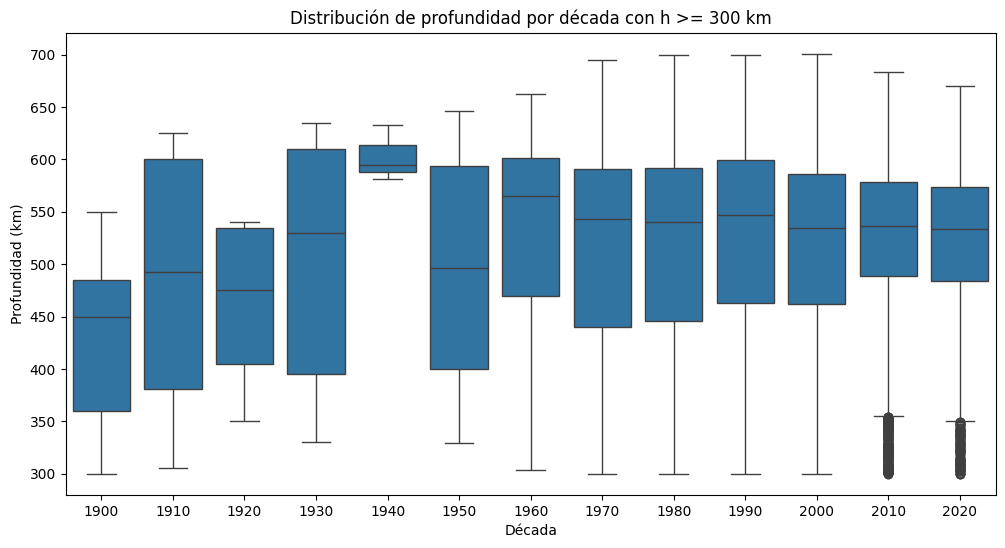

In [24]:
df_prof_alta = df[df['depth'] >= 300]
df['decade'] = (df['year'] // 10) * 10

plt.figure(figsize=(12,6))
sns.boxplot(data=df_prof_alta, x='decade', y='depth')
plt.title('Distribución de profundidad por década con h >= 300 km')
plt.xlabel('Década')
plt.ylabel('Profundidad (km)')
plt.show()

En este plot se analiza la evolución temporal de la profundidad de los sismos, pero considerando solo los de profundidad mayor a 300 km. Nuevamente se observa la poca densidad de sismos entre los 300 a 450 km más o menos, como ya se mencionaron, también se observa que aumento la profundidad a la que se detectan los sismos, a inicios del siglo pasado la mayor profundidad registrada estaba bajo 650 km, en cambio a fines del siglo pasado junto con comienzos de este se ve que la mayor profundidad es 700 km más o menos.   

<>:6: SyntaxWarning: invalid escape sequence '\g'
<>:6: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_221431/188601862.py:6: SyntaxWarning: invalid escape sequence '\g'
  plt.ylabel('Proporción de sismos depth $\geq$ 450 km')


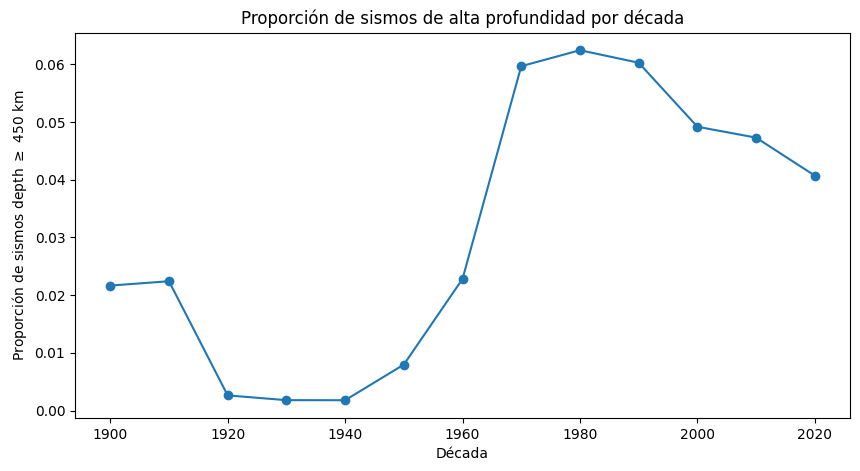

In [25]:
df['prof_alta'] = df['depth'] > 300
prop_bajos = df.groupby('decade')['prof_alta'].mean()

plt.figure(figsize=(10,5))
prop_bajos.plot(marker='o')
plt.ylabel('Proporción de sismos depth $\geq$ 450 km')
plt.xlabel('Década')
plt.title('Proporción de sismos de alta profundidad por década')
plt.show()

Siguiendo la misma idea que el plot anterior, se puede ver como hay una aumento en la proporción de sismos a gran profundidad (h > 300 km), seguramente esto se deba al avance tecnologico. 

Pongamos el foco ahora en las localidades, para ver si matienen alguna relación marcada con la profundidad de los sismos.

<>:20: SyntaxWarning: invalid escape sequence '\g'
<>:20: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_221431/1352461787.py:20: SyntaxWarning: invalid escape sequence '\g'
  plt.title('Top 10 Países/Regiones cantidad de Sismos más Profundos (h $\geq$ 300 km)', fontsize=13, pad=15)


Top países con sismos más profundos h >= 300 (km):
pais_region
Indonesia           49
Japan               36
Papua New Guinea    27
Chile               25
Peru                24
Philippines         24
Russia              22
Mexico              19
Alaska              15
Solomon Islands     14
Name: count, dtype: int64


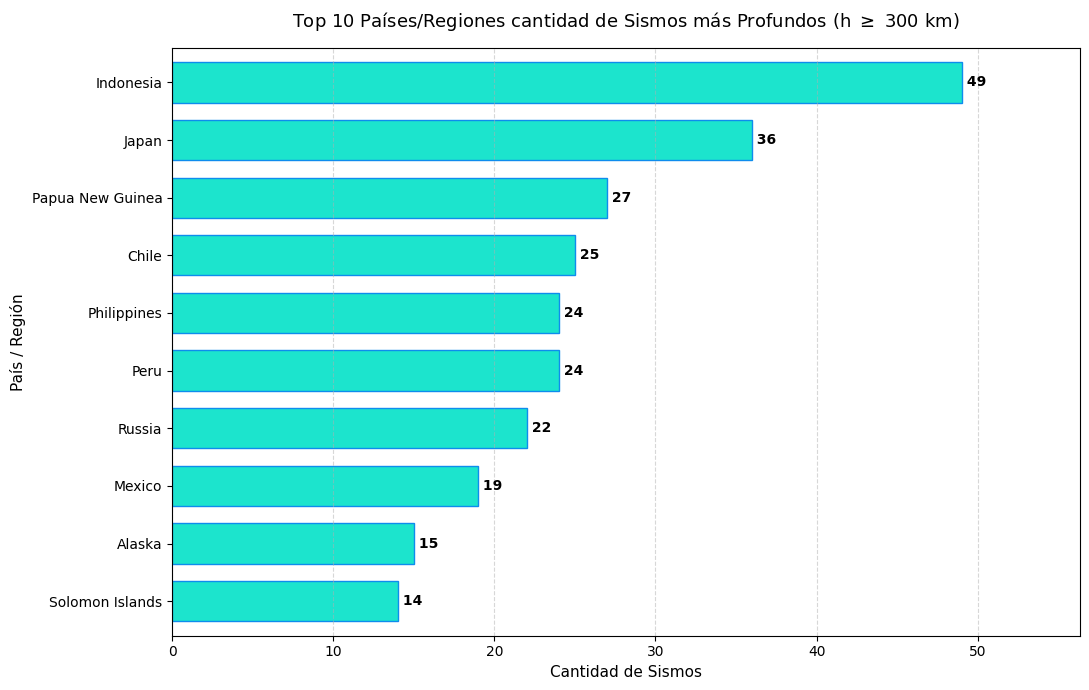

In [26]:
mayor_h = df[df['depth'] >= 300]
top10_paises_mayorh = terremotos['pais_region'].value_counts().head(10)
print("Top países con sismos más profundos h >= 300 (km):")
print(top10_paises_mayorh.head(10))

plt.figure(figsize=(11, 7))

# Graficar ordenando de menor a mayor para que el país #1 quede arriba
top10_paises_mayorh.sort_values(ascending=True).plot(
    kind='barh', 
    color="#1ce4cd", 
    edgecolor="#0e8ced",
    width=0.7
)

# Añadir etiquetas con el número exacto al final de cada barra
for index, value in enumerate(top10_paises_mayorh.sort_values(ascending=True)):
    plt.text(value, index, f' {value:,}', va='center', fontsize=10, fontweight='bold')

plt.title('Top 10 Países/Regiones cantidad de Sismos más Profundos (h $\geq$ 300 km)', fontsize=13, pad=15)
plt.xlabel('Cantidad de Sismos', fontsize=11)
plt.ylabel('País / Región', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Extender el límite del eje X para que quepan los números de la etiqueta
plt.xlim(0, top10_paises.max() * 1.15)

plt.tight_layout()
plt.show()

Visualización numérica de los 10 países con sismos más profundos, como ya sabiamos son practicamente los mismos países con mayor cantidad de sismos registrados. El ranking lo lidera Indonesia con 49 sismos registrados a más de 300 km de profundidad, le sigue Japón, Papua Nueva Guinea y Chile.  

### **FIGURA CLAVE**

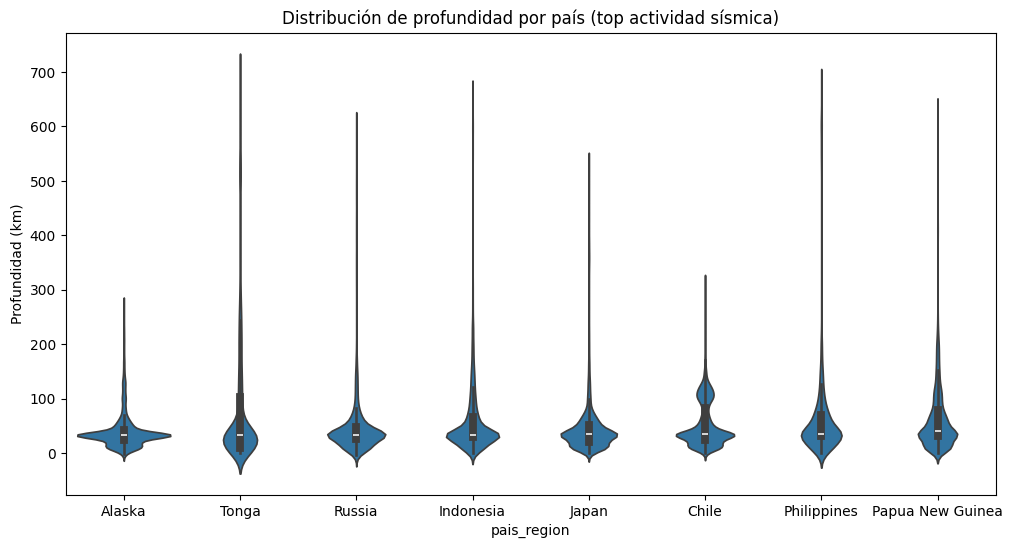

In [27]:
top_paises_actividad = df['pais_region'].value_counts().head(8).index

df_top_actividad = df[df['pais_region'].isin(top_paises_actividad)]

plt.figure(figsize=(12,6))
sns.violinplot(data=df_top_actividad, x='pais_region', y='depth', order=df_top_actividad.groupby('pais_region')['depth'].median().sort_values().index)
plt.ylabel('Profundidad (km)')
plt.title('Distribución de profundidad por país (top actividad sísmica)')
plt.show()

#### ¿Qué pregunta responde?

Esta figura responde si el lugar donde ocurre un sismo tiene relación con su profundidad, es decir, si distintas zonas del mundo muestran distribuciones de profundidad distintas entre ellas.

#### ¿Qué patrón muestra?

Se puede observar que las medianas de profundidad se mantienen bastante parecidas entre los distintos países, ya que la mayoría de los sismos, en cualquier lugar, ocurren en profundidades bajas. Sin embargo, el rango de profundidades sí cambia según el país. Algunos países llegan a tener sismos de hasta 600-700 km de profundidad, mientras que otros, se concentran en un rango mucho más acotado. También es posible observar una distribución bimodal en Chile, donde la mediana está en bajas profundidades pero la distribución aumenta también en el rango de 100-200 km.

#### ¿Por qué es importante para su interpretación?

Esta figura es importante porque evita sacar una conclusión equivocada ya que si solo se mirara la mediana de profundidad, se podría pensar que el lugar no tiene relación con la profundidad de los sismos. Pero al ver la distribución completa, se nota que el lugar sí influye en el rango máximo de profundidad que se puede alcanzar, lo cual estaría relacionado con la geometría y distribución de placas de cada zona.

### **CONCLUSIÓN PREGUNTA INVESTIGACIÓN**

Quedo evidenciado que la profundidad de los sismos si depende del lugar, lo cual se debe a la deriva continental, donde las placas tectónicas sobre las cuales vivimos todos nosotros, están en constante movimiento. Algunas se mueven alejandose y otras se acercan, estos diferentes movimientos causan los sismos y terremotos. Por lo cual, en donde limitan unas placas de otras es donde habrá mayor cantidad de sismos, a magnitudes altas y grandes profundidades en la mayoría de los casos. 

### **POSIBLE PROBLEMA DE MACHINE LEARNING**

#### ¿Qué intentarían predecir?

Para poder seguir con el trabajo se propone entrenar un modelo para predecir la profundidad del sismo. 
Como vimos anteriormente, hay una relación entre el lugar del sismo y la profundidad de este. Aunque el promedio de profundidades se mantiene parecido para la mayoría de los lugares, otras características de este pueden ayudar al modelo a llegar a una predicción.

#### ¿Qué features utilizarían como información de entrada?

Las features que se utilizarían serían la longitud, la latitud y la magnitud. De acuerdo a relaciones entre la profundidad con el lugar y la magnitud, se estima que estas features están más correlacionadas a la profundidad.


#### ¿Sería un problema de clasificación o de regresión? ¿Por qué?
Este sería un problema de regresión en el cual el modelo predice un valor para la profundidad. Si se quisiera separar las profundidades en categorías de "superficial" o "profundo" en vez de un valor, sería un problema de clasificación.

#### ¿Qué observaciones de su EDA sugieren que podría existir información útil para realizar esa predicción?

Se vio anteriormente en los gráficos que hay una relación tanto entre profundidad y el lugar del sismo. Si bien la profundidad típica (mediana) es similar entre la mayoría de los lugares, el rango máximo de profundidad alcanzable varía mucho según cada zona; algunos países muestran rangos de profundidad mucho más extendidos que otros. También se tiene una relación entre la profundidad y la magnitud del sismo, la cual nos mostró para magnitudes entre 6 y 7 una distribución bimodal entre profundidades altas y bajas, y para magnitudes mayores una profundidad más baja.

#### ¿Qué dificultades anticipan? Por ejemplo: datos faltantes, clases desbalanceadas, pocas observaciones, outliers, features muy relacionadas entre sí o posibles sesgos en la muestra.

La profundidad de los sismos es una variable muy desequilibrada. Hay muchos más sismos de baja profundidad que de alta, por lo que el modelo puede tender a preferir una profundidad más baja.

La misma distribución bimodal presente en el gráfico de profundidad en función de la magnitud presenta una dificultad a la hora de predecir la profundidad, ya que añade más posibilidades. También, en el mismo gráfico, se observa que a magnitudes más bajas la distribución de profundidades es más variada. 

Además, para una mayor precisión y para evitar falsas predicciones, harían falta datos adicionales como algún indicador de qué tan destructivo fue cada sismo (en caso de estar en alguna ciudad) para poder diferenciar entre profundidades altas y bajas. Otra feature interesante es la distancia a la fosa oceánica, ya que esta estaría directamente relacionada con la profundidad.